# Mandat no 1 - Statistiques descriptives et inférence statistique

Mise en place pour le mandat.

In [12]:
# Probabilités
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import math
from IPython.display import display, Math, Markdown

In [3]:
class statistik:
    
    def __init__(self):
        pass

    # On compte le nombre de façons d'arranger les éléments
    def permutation(self, n, r: int | list | None, type: str | None):
        match type:
            case None:
                return math.factorial(n)
            case "subset":
                if r is None:
                    raise TypeError
                return math.factorial(n) / math.factorial(n-r)
            case "sim-object":
                if r is None:
                    raise TypeError
                denum = 1
                for v in r:
                    denum *= math.factorial(v)
                return math.factorial(n) / denum
            
    # On compte le nombre de façons d'arranger les éléments sans tenir compte de l'ordre
    def combinaison(self, n, r):
        return math.factorial(n) / (math.factorial(r) * math.factorial(n-r))
    

In [4]:
class distribution:
    
    def __init__(self, stat: statistik):
        self.stat = stat

    def P(self):
        raise NotImplementedError("Subclasses must implement this method")
    
    def P_cumul(self):
        raise NotImplementedError("Subclasses must implement this method")
    
    def E(self):
        raise NotImplementedError("Subclasses must implement this method")
    
    def E_cuml(self):
        raise NotImplementedError("Subclasses must implement this method")

    def V(self):
        raise NotImplementedError("Subclasses must implement this method")
    
    def V_cumul(self):
        raise NotImplementedError("Subclasses must implement this method")
    
    def cumul(self):
        raise NotImplementedError("Subclasses must implement this method")

In [5]:
class binomial_distribution(distribution):

    def P(self, n, x, p):
        return self.stat.combinaison(n, x) * p**x * (1-p)**(n-x)
    
    def P_cumul(self, n, x, p):
        Ps = np.array(x, dtype=float)
        for i, v in enumerate(x):
            Ps[i] = self.P(n, v, p)
        return np.sum(Ps)
    
    def E(self, n, p):
        return n * p
    
    def E_cuml(self, n, x, p):
        Ps = np.array(x, dtype=float)
        Es = np.array(x, dtype=float)
        for i, v in enumerate(x):
            P = self.P(n, v, p)
            Ps[i] = P
            Es[i] = v * P
        return np.sum(Es)

    def V(self, n, p):
        return n * p * (1-p)
    
    def V_cumul(self, n, x, p):
        Ps = np.array(x, dtype=float)
        Es = np.array(x, dtype=float)
        Vs = np.array(x, dtype=float)
        for i, v in enumerate(x):
            P = self.P(n, v, p)
            Ps[i] = P
            Es[i] = v * P
            Vs[i] = (v - Es[i])**2 * P
        return np.sum(Vs)
    
    def cumul(self, n, x, p):
        Ps = np.array(x, dtype=float)
        Es = np.array(x, dtype=float)
        Vs = np.array(x, dtype=float)
        for i, v in enumerate(x):
            P = self.P(n, v, p)
            Ps[i] = P
            Es[i] = v * P
            Vs[i] = (v - Es[i])**2 * P
        return np.sum(Ps), np.sum(Es), np.sum(Vs)

In [6]:
class machine_a_sous:
    def __init__(self, roues, pictos):
        self.roues = roues
        self.pictos = pictos

    def probabilite_win(self):
        # Calcul de la probabilité de gagner
        return 1 * (1 / self.pictos)**(self.roues - 1) # Probabilité d'obtenir un pictogramme spécifique sur une roue
    
    

In [7]:
stat = statistik()
# 3 roues, 8 pictogrammes
machine1 = machine_a_sous(3, 8)
# 4 roues, 5 pictogrammes
machine2 = machine_a_sous(4, 5)

## i) Configuration des roues

Comparaison des probabilité où tout les pictogrammes sont identiques: $P=\left(\frac{1}{s}\right)^{r-1}$, où $r$ est le nombre de roues et $s$ le nombre de pictogrammes par roue.

In [8]:
# i
print(f"Probabilité de gagner un pouvoir à la machine 1 (3 roues, 8 pictogrammes): {machine1.probabilite_win()*100:.2f}%")
print(f"Probabilité de gagner un pouvoir à la machine 2 (4 roues, 5 pictogrammes): {machine2.probabilite_win()*100:.2f}%")

Probabilité de gagner un pouvoir à la machine 1 (3 roues, 8 pictogrammes): 1.56%
Probabilité de gagner un pouvoir à la machine 2 (4 roues, 5 pictogrammes): 0.80%


## ii) Permutation des combinaisons

Comparaison des combinaisons des différentes configurations de roues.

On utilise les permutations, $P(m,r)=\frac{m!}{(m-r)!}$

In [9]:
#ii
# On va utiliser la permutation pour avoir toutes les façons d'arranger les éléments
print(f"Permutation de machine 1 : {stat.permutation(machine1.pictos, machine1.roues, "subset"):.0f}")
print(f"Permutation de machine 2 : {stat.permutation(machine2.pictos, machine2.roues, "subset"):.0f}")

Permutation de machine 1 : 336
Permutation de machine 2 : 120


## iii) Distribution binomiale

On cherche $P(X\ge2)=1-[P(X=0)+P(X=1)]$, avec $P(X=x)=\binom{5}{x}p^x(1-p)^{5-x}$.

Où $x$ est le nombre d'essai réussi.

Avoir le même pictogramme sur l'ensemble des roues au moins 2 fois sur un total de 5 essais :
Machine 1 : 
	 Probabilité cumulative : 0.2366%
	 Moyenne : 0.0048
	 Variance : 0.0096
Machine 2 : 
	 Probabilité cumulative : 0.0630%
	 Moyenne : 0.0013
	 Variance : 0.0025


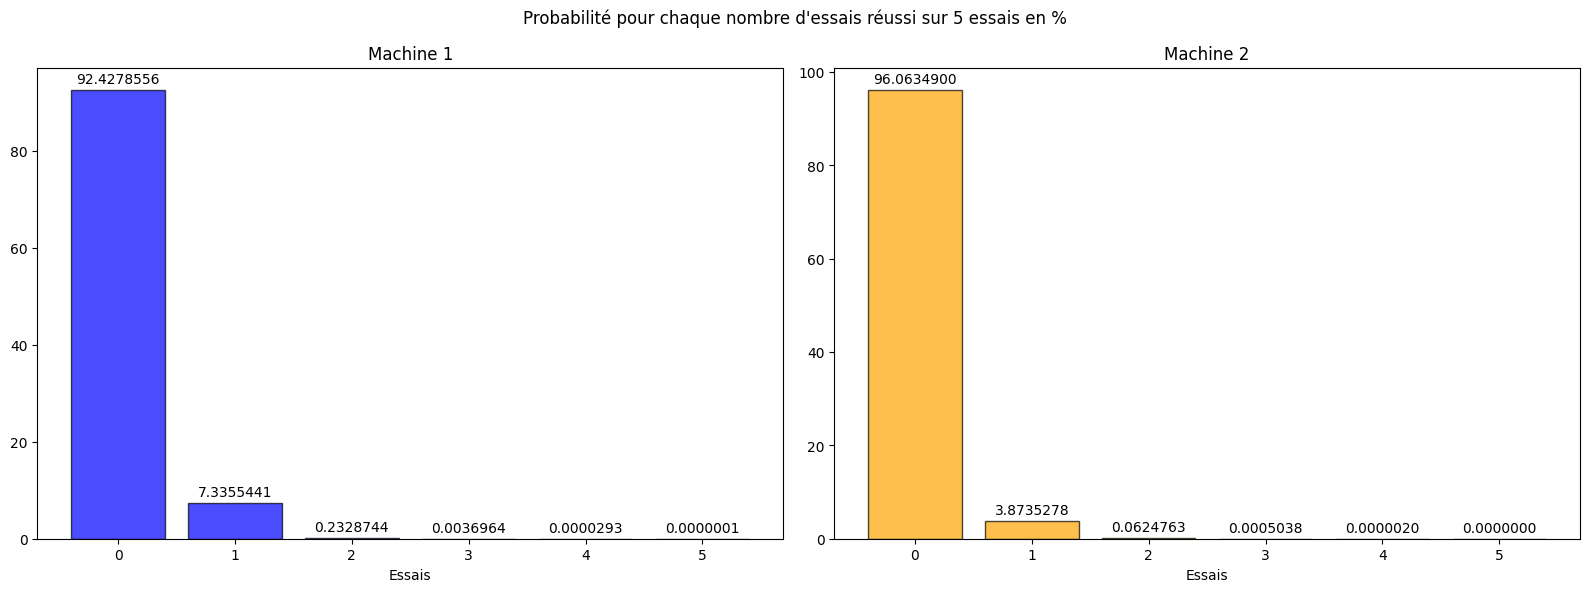

In [10]:
# iii
print("Avoir le même pictogramme sur l'ensemble des roues au moins 2 fois sur un total de 5 essais :")
plt.figure(figsize=(16, 6))
n = 5 # Essais
x = np.arange(6)
bd = binomial_distribution(stat)

p = machine1.probabilite_win() # Probabilité d'avoir le même pictogramme sur toutes les roues
P, E, V = bd.cumul(n, x[2::], p)
print("Machine 1 : ")
print(f"\t Probabilité cumulative : {P*100:.4f}%")
print(f"\t Moyenne : {E:.4f}")
print(f"\t Variance : {V:.4f}")

Ps = np.array([
    bd.P(n, 0, p),
    bd.P(n, 1, p),
    bd.P(n, 2, p),
    bd.P(n, 3, p),
    bd.P(n, 4, p),
    bd.P(n, 5, p),
]) * 100

plt.subplot(1, 2, 1)
plt.bar(x, Ps, alpha=0.7, color='blue', edgecolor='black')
for i in range(len(Ps)):
    plt.annotate(f"{Ps[i]:.7f}", xy=(x[i], Ps[i]), xytext=(0, 5),
                 textcoords="offset points", ha='center')
plt.title(f"Machine 1")
plt.xlabel("Essais")

p = machine2.probabilite_win() # Probabilité d'avoir le même pictogramme sur toutes les roues
P, E, V = bd.cumul(n, x[2::], p)
print("Machine 2 : ")
print(f"\t Probabilité cumulative : {P*100:.4f}%")
print(f"\t Moyenne : {E:.4f}")
print(f"\t Variance : {V:.4f}")

Ps = np.array([
    bd.P(n, 0, p),
    bd.P(n, 1, p),
    bd.P(n, 2, p),
    bd.P(n, 3, p),
    bd.P(n, 4, p),
    bd.P(n, 5, p),
]) * 100

plt.subplot(1, 2, 2)
plt.bar(x, Ps, alpha=0.7, color='orange', edgecolor='black')
for i in range(len(Ps)):
    plt.annotate(f"{Ps[i]:.7f}", xy=(x[i], Ps[i]), xytext=(0, 5),
                 textcoords="offset points", ha='center')
plt.title(f"Machine 2")
plt.xlabel("Essais")


plt.suptitle('Probabilité pour chaque nombre d\'essais réussi sur 5 essais en %')
plt.tight_layout()
plt.show()




# Mandat no 1.2 - Jeu de fléchette

Les axes $(X,Y)$ sont indépendants lors d'un lancer de fléchette donc la corrélation $\rho_{XY}=0$, ce qui implique que la covariance $Cov(X,Y)=0$.

Avec une position $(X,Y)$, on utilise la fonction de densité normal bivarié pour calculer la probabilité $P(X,Y)$ d'une variable aléatoire à deux dimensions à l'aide d'une double intégral. La position a une moyenne située au centre $(\mu_x, \mu_y) = (0,0)$ de la cible avec un équart-type $\sigma_x=0.1$ et $\sigma_y\in\{0.05,0.4\}$ selon $z$. On s'intéresse à la probabilité de réussir a envoyer les fléchettes dans le cercle du millieu de la cible de rayon de $0.1$ m.

Puisque $P(X,Y)$ n'est pas assez précis, on utilise une approximation de Monte-Carlo avec 1 millions de points.

In [11]:
# Jeu de fléchette

def f_xy(x, y, o_x, o_y, u_x, u_y, p):
    const = (1/(2*sp.pi*o_x*o_y*sp.sqrt(1-p**2)))
    a = 1 / (2*(1-p**2))
    b = (x-u_x)**2 / o_x**2
    c = 2*p * ((x-u_x)*(y-u_y)) / (o_x*o_y)
    d = (y-u_y)**2 / o_y**2
    exp = sp.exp(-a * (b - c + d))
    return const*exp

def probability_z(z):

    x, y, o_x, o_y, u_x, u_y, p = sp.symbols('x y o_x o_y u_x u_y p')

    r = 0.1

    u_x = 0
    u_y = 0
    o_x = 0.1

    if z > 10:
        o_y = 0.4
    elif z < 1:
        o_y = 0.05

    p = 0 # aucune corrélation entre x et y
    cov = 0 # puisque p = 0

    fxyz = f_xy(x, y, o_x, o_y, u_x, u_y, p)
    fxz = fxyz.subs({y:0})
    fyz = fxyz.subs({x:0})
    P = sp.integrate(fxyz, (x, -r, r), (y, -sp.sqrt(r**2 - -r**2), sp.sqrt(r**2 - r**2)))


    print(f"Aucune corrélation entre x et y donc p = {p}")
    print(f"Si p = {0} alors la covariance cov = {cov}")

    print()
    print(f'Pour z = {z} : ')

    display(Math(f' f(x,y|z) = {sp.latex(fxyz)}'))
    display(Math(f' f(x|z) = {sp.latex(fxz)}'))
    display(Math(f' f(y|z) = {sp.latex(fyz)}'))
    display(Markdown(f" Probabilité à l\'aide de $f(x,y|z)$ = {P*100:.4f}%"))

    N = 1_000_000
    A = np.pi * r**2

    x = np.random.normal(u_x, o_x, N)
    y = np.random.normal(u_y, o_y, N)

    inside = (x**2 + y**2) <= r**2
    N1 = np.sum(inside)

    P = N1/N
    display(Markdown(f' Probabilité à l\'aide de Monte-Carlo = {P*100:.4f}%'))

probability_z(0.5)
print('------------------------------------------------------------------------')
probability_z(20)






Aucune corrélation entre x et y donc p = 0
Si p = 0 alors la covariance cov = 0

Pour z = 0.5 : 


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

 Probabilité à l'aide de $f(x,y|z)$ = 33.9748%

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

 Probabilité à l'aide de $f(x,y|z)$ = 9.4323%

 Probabilité à l'aide de Monte-Carlo = 11.0466%